Task 1: Data Understanding and Visualization:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI & ML/Week5/Copy of FruitinAmazon.zip'
extract_path = "dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done!")

Extraction done!


In [ ]:
train_dir = "dataset/FruitinAmazon/train"

# Check structure
print(os.listdir("dataset"))
print(os.listdir(train_dir))

['FruitinAmazon']
['graviola', 'pupunha', 'acai', 'cupuacu', 'guarana', 'tucuma']


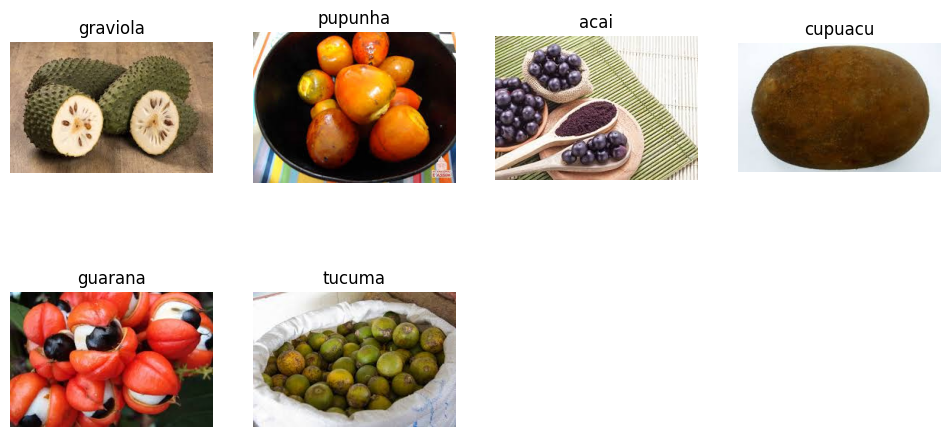

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = os.listdir(train_dir)

plt.figure(figsize=(12,6))

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

Check for Corrupted Image

In [ ]:
corrupted = []

for cls in os.listdir(train_dir):
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


Task 2: Loading and Preprocessing Image Data in keras

In [ ]:
import tensorflow as tf

img_height = 128
img_width = 128
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# Normalize
rescale = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


Task 3 - Implement a CNN

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4: Compile the Model

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
model = models.Sequential([
    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Task 4: Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(patience=10, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.0793 - loss: 2.2054

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 660ms/step - accuracy: 0.0972 - loss: 2.3627 - val_accuracy: 0.0556 - val_loss: 1.8190
Epoch 2/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 580ms/step - accuracy: 0.1250 - loss: 1.9032 - val_accuracy: 0.0556 - val_loss: 1.8083
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 925ms/step - accuracy: 0.1667 - loss: 1.7929 - val_accuracy: 0.0556 - val_loss: 1.7991
Epoch 4/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 815ms/step - accuracy: 0.1667 - loss: 1.7857 - val_accuracy: 0.0556 - val_loss: 1.7978
Epoch 5/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.1528 - loss: 1.8037 - val_accuracy: 0.0556 - val_loss: 1.8010
Epoch 6/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 559ms/step - accuracy: 0.1389 - loss: 1.7800 - val_accuracy: 0.0556 - val_loss: 1.8116
Epoch 7/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 503ms/step - accuracy: 0.3056 - loss: 1.7742 - val_accuracy: 0.0556 - val_loss: 1.8180
Epoch 8/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.2500 - loss: 1.7781 - val_accuracy: 0.0556 - val_loss: 1.8296
Epo

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 981ms/step - accuracy: 0.2361 - loss: 1.7492 - val_accuracy: 0.1111 - val_loss: 1.9429
Epoch 11/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.1667 - loss: 1.7658 - val_accuracy: 0.1111 - val_loss: 1.8988
Epoch 12/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.2917 - loss: 1.7064 - val_accuracy: 0.1111 - val_loss: 1.9254
Epoch 13/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 516ms/step - accuracy: 0.2083 - loss: 1.6811 - val_accuracy: 0.1111 - val_loss: 1.8600
Epoch 14/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 508ms/step - accuracy: 0.3056 - loss: 1.6187 - val_accuracy: 0.1111 - val_loss: 1.9633


Task 5: Evaluate the Model

In [ ]:
loss, acc = model.evaluate(val_ds)
print("Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.2778 - loss: 1.5244
Accuracy: 0.2777777910232544


Task 6: Save and Load the Model

In [ ]:
model.save("final_model.keras")

In [ ]:
from tensorflow.keras.models import load_model
loaded_model = load_model("best_model.h5")

Task 7: Predictions and Classification Report

In [ ]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.2778 - loss: 1.5244
Loaded Model Accuracy: 0.2777777910232544


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
              precision    recall  f1-score   support

        acai       0.07      1.00      0.12         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       0.00      0.00      0.00         3

    accuracy                           0.06        18
   macro avg       0.01      0.17      0.02        18
weighted avg       0.00      0.06      0.01        18



Keys in history.history: dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


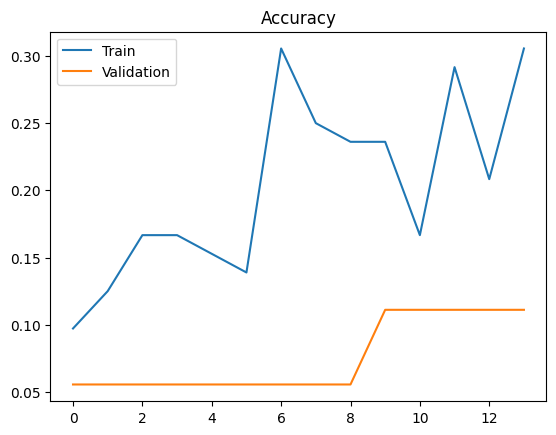

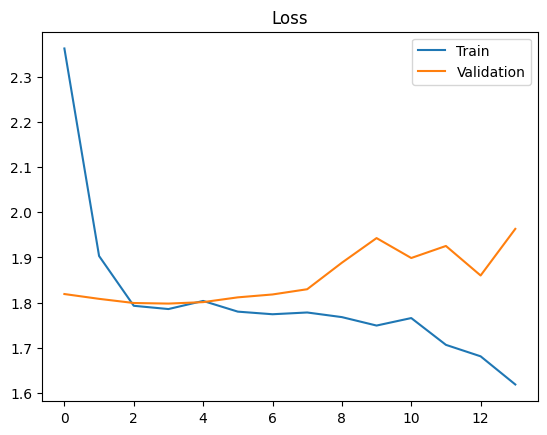

In [ ]:
import matplotlib.pyplot as plt

print("Keys in history.history:", history.history.keys())

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

**Accuracy Graph:**
Training accuracy improves gradually, but validation accuracy fluctuates and remains low --> indicates poor generalization.

**Loss Graph:**
Training loss decreases steadily, but validation loss does not improve consistently --> further evidence of overfitting.

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Collect true labels and predictions
y_true = []
y_pred = []

for images, labels in val_ds:   # use test_ds if you have a separate test set
    preds = loaded_model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.06      1.00      0.11         1
     cupuacu       0.00      0.00      0.00         2
    graviola       0.00      0.00      0.00         3
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         4
      tucuma       1.00      0.33      0.50         3

    accuracy                           0.11        18
   macro avg       0.18      0.22      0.10        18
weighted avg       0.17      0.11      0.09        18



The model’s accuracy can be improved by handling class imbalance using class weights, applying stronger data augmentation, and tuning hyperparameters. However, the most effective approach is to use transfer learning with a pre-trained model, as it performs better on small datasets and reduces overfitting